# Magnetization Relaxation in `LambdaLLG`

This notebook demonstrates a simple relaxation problem in both one and two spatial dimensions.
The setup is intentionally minimal: we begin from random in-plane spins, evolve the Landau-Lifshitz-Gilbert dynamics, and then inspect how the magnetization settles over time.

For reference, the Gilbert form of the equation of motion is

$$
\frac{d\mathbf{m}}{dt} = -\mathbf{m} \times \mathbf{H}_{\mathrm{eff}} + \alpha_G \, \mathbf{m} \times \frac{d\mathbf{m}}{dt},
$$

where exchange, anisotropy, and the external field are encoded through the effective field $\mathbf{H}_{\mathrm{eff}}$.

In [1]:
# Activate the package environment in the repository root.
using Pkg; Pkg.activate("../")

  Activating project at `C:\Users\freye\PersonalCode\LambdaLLG.jl`


In [2]:
# Load the solver package and plotting tools used in this notebook.
using LambdaLLG
using LinearAlgebra

import PyPlot as plt

## 1D Example

We first study a one-dimensional chain.
The anisotropy and external field point along $+z$, so the random initial state is expected to relax toward positive $m_z$.

In [3]:
# One-dimensional model parameters.
Nx = 20

J = 1.0

K = (0.0, 0.0, 0.1)

αG = 0.1

B_ext = (0.0, 0.0, 0.5)

# Build the 1D parameter object.
par_1d = LLGParams1D(
    Nx,                    # Number of sites
    J,                     # Heisenberg exchange
    K,                     # Anisotropy vector
    B_ext,                 # External field
    αG                     # Gilbert damping
    );

### Initial State

The chain is initialized with spins in the $xy$ plane.
Each site gets a random azimuthal angle, so initially the $z$ component is zero everywhere.

In [4]:
# Allocate a 3 x Nx spin array.
s0_1d = zeros(3, Nx)

# Fill each site with a random in-plane spin.
for n in 1:Nx
    phi = rand()*2π
    s0_1d[1,n] = cos(phi)
    s0_1d[2,n] = sin(phi)
end

### Time Evolution

We now evolve the chain over a fixed relaxation window.
`format_results` converts the solution object into a dense array with the first column storing time.

In [5]:
# Integrate the 1D dynamics and store the formatted output.
t_relax = (0.0,100)

sol_1d = evolve1D(s0_1d, t_relax, par_1d)

data_1d = format_results(sol_1d);

### Average Magnetization

The formatted data stores spin components in the pattern
$[t, m^x_1, m^y_{1}, m^z_{1}, m^x_{2}, \ldots]$.
The next cell averages each component over all sites in the chain.

In [6]:
# Average the x, y, and z components over all lattice sites.
avg_x_1d = sum(data_1d[:,2:3:end]/Nx, dims=2)
avg_y_1d = sum(data_1d[:,3:3:end]/Nx, dims=2)
avg_z_1d = sum(data_1d[:,4:3:end]/Nx, dims=2);

### 1D Plots

The first panel tracks a single site, while the second panel shows the chain-averaged magnetization.
The color convention is blue for $m_x$, green for $m_y$, and red for $m_z$.

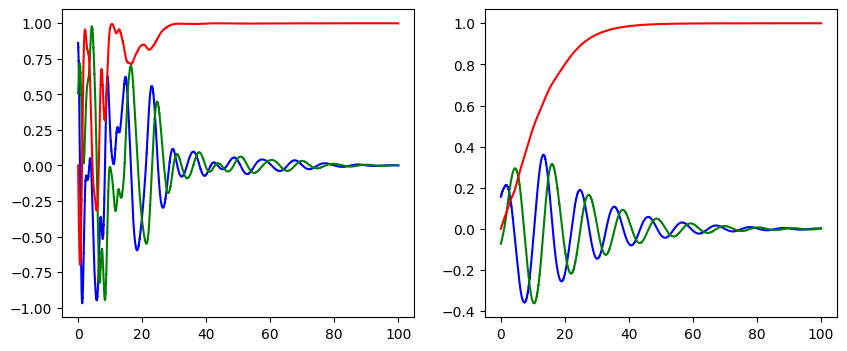

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x0000024FC3CD75D0>

In [7]:
# Plot one representative site together with the chain average.
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

site = 10

ax[1].plot(data_1d[:,1], data_1d[:,site*3-1], "b")
ax[1].plot(data_1d[:,1], data_1d[:,site*3], "g")
ax[1].plot(data_1d[:,1], data_1d[:,site*3+1], "r")

ax[2].plot(data_1d[:,1], avg_x_1d, "b")
ax[2].plot(data_1d[:,1], avg_y_1d, "g")
ax[2].plot(data_1d[:,1], avg_z_1d, "r")

## 2D Example

We repeat the same basic workflow on a two-dimensional lattice.
This makes it possible to inspect not only averaged time traces, but also snapshots of the spatial texture.

In [8]:
# Reuse the same material parameters on a 2D grid.
Nx = 20
Ny = 30

# Build the 2D parameter object.
par_2d = LLGParams2D(
    Nx,                    # Number of sites in x
    Ny,                    # Number of sites in y
    J,                     # Heisenberg exchange
    K,                     # Anisotropy vector
    B_ext,                 # External field
    αG                     # Gilbert damping
    );

### Initial State

As in 1D, the 2D lattice starts with random in-plane spins.
This produces a disordered initial texture that will relax under damping.

In [9]:
# Allocate a 3 x Nx x Ny spin array.
s0_2d = zeros(3, Nx, Ny)

# Fill every lattice site with a random in-plane spin.
for ny in 1:Ny, nx in 1:Nx
    phi = rand()*2π
    s0_2d[1,nx,ny] = cos(phi)
    s0_2d[2,nx,ny]  = sin(phi)
end

### Time Evolution

The same relaxation window is used here.
The output is again converted into a dense time-and-state array.

In [10]:
# Integrate the 2D dynamics and store the formatted output.
sol_2d = evolve2D(s0_2d, t_relax, par_2d)

data_2d = format_results(sol_2d);

### Average Magnetization

The averaging step is now taken over all $N_x N_y$ lattice sites.
This gives the net magnetization of the full 2D sample as a function of time.

In [11]:
# Average the x, y, and z components over the full 2D grid.
avg_x_2d = sum(data_2d[:,2:3:end]/Nx/Ny, dims=2)
avg_y_2d = sum(data_2d[:,3:3:end]/Nx/Ny, dims=2)
avg_z_2d = sum(data_2d[:,4:3:end]/Nx/Ny, dims=2);

### 2D Plots

The top row plots the time trace of one selected lattice site and the lattice-averaged magnetization.
The bottom row reshapes two solver states into $3 \times N_x \times N_y$ arrays and visualizes the $m^z$ component at an early time and at the end of the simulation.

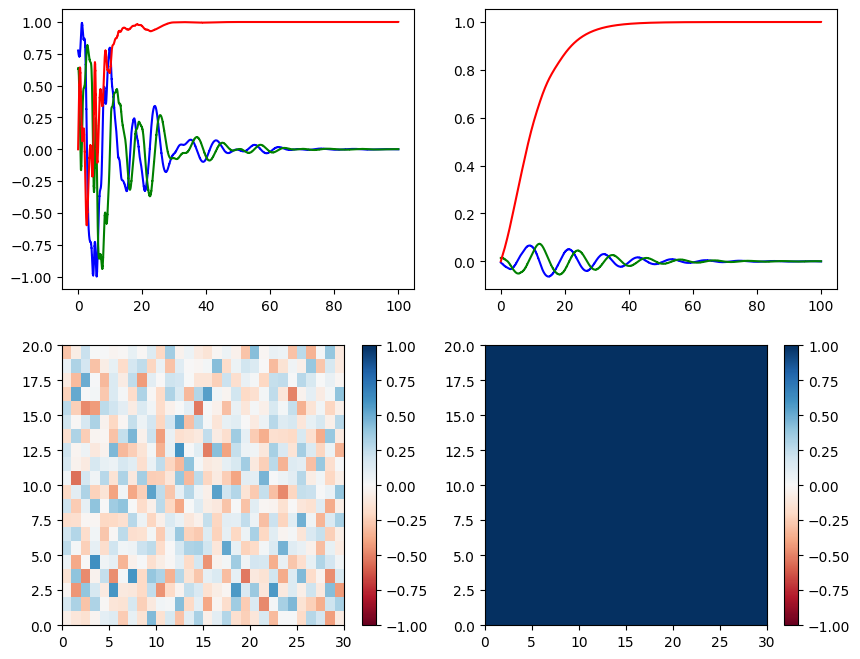

PyObject <matplotlib.colorbar.Colorbar object at 0x0000024FCE176AD0>

In [12]:
# Plot a single-site trace, the full average, and two mz snapshots.
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,8))

sitex = 10

sitey = 5

linsite = (Ny - 1) * sitex + sitey

ax[1,1].plot(data_2d[:,1], data_2d[:,linsite*3-1], "b")
ax[1,1].plot(data_2d[:,1], data_2d[:,linsite*3], "g")
ax[1,1].plot(data_2d[:,1], data_2d[:,linsite*3+1], "r")

ax[1,2].plot(data_2d[:,1], avg_x_2d, "b")
ax[1,2].plot(data_2d[:,1], avg_y_2d, "g")
ax[1,2].plot(data_2d[:,1], avg_z_2d, "r")

# Compare an early configuration with the final relaxed state.
early_state = reshape(sol_2d.u[10], 3, Nx, Ny)
final_state = reshape(sol_2d.u[end], 3, Nx, Ny)

im1 = ax[2,1].pcolormesh(early_state[3,:,:], cmap="RdBu", vmin=-1, vmax=1)
fig.colorbar(im1)

im2 = ax[2,2].pcolormesh(final_state[3,:,:], cmap="RdBu", vmin=-1, vmax=1)
fig.colorbar(im2)

## Summary

In both 1D and 2D, the random in-plane initial condition relaxes under damping in the presence of anisotropy and an external $z$-field.
The time traces show how local spins and spatial averages evolve, while the 2D snapshots show the texture becoming more aligned over time.